In [2]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com' # Set Hugging Face endpoint to a mirror
os.chdir('./Interkcat')

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from model import InterKcat, KcatDataset, collate_fn
from torch.utils.data import Dataset, DataLoader

In [4]:
# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 1234
EPOCHS = 200

df = pd.read_csv('EITLEM_KCAT.csv')
sequences = df['Sequence'].to_list()
smiles_list = df['Smiles'].to_list()
kcats = np.log10(df['Value']).values

# Split  Train : Dev : Test = 80 : 10 : 10
train_seq, temp_seq, train_smiles, temp_smiles, train_kcat, temp_kcat = train_test_split(
        sequences, smiles_list, kcats,
        test_size=0.2,
        random_state=SEED
    )


dev_seq, test_seq, dev_smiles, test_smiles, dev_kcat, test_kcat = train_test_split(
    temp_seq, temp_smiles, temp_kcat,
    test_size=0.5,
    random_state=SEED
)

# Dataset
train_dataset = KcatDataset(train_seq, train_smiles, train_kcat)
dev_dataset = KcatDataset(dev_seq, dev_smiles, dev_kcat)
test_dataset = KcatDataset(test_seq, test_smiles, test_kcat)

### Model apply for mutant influence prediction

In [5]:
from tqdm import tqdm

# Load best model and evaluate on test set
model_path = './interkcat_both_lr0.0001_bs128_md256/best_interkcat_model.pth'
model = InterKcat(prot_dim=640, mol_dim=256).to(DEVICE)
model.load_state_dict(torch.load(model_path))
model.eval()

BATCH_SIZE = 256
df = pd.read_csv('EITLEM_KCAT_with_mutations_dev_test.csv')
sequences = df['Sequence'].to_list()
smiles_list = df['Smiles'].to_list()
kcats = np.log10(df['Value']).values
dataset = KcatDataset(sequences, smiles_list, kcats)
data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

all_preds = []
with torch.no_grad():
    for seq_batch, smiles_batch, kcat_batch in tqdm(data_loader):
        kcat_pred = model(
            protein_sequences=seq_batch,
            smiles_list=smiles_batch,
            inter_model="both"
        )
        all_preds.extend(kcat_pred.cpu().numpy())
    all_preds = np.array(all_preds)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|███████████████████████████████████████████| 27/27 [03:19<00:00,  7.39s/it]


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset with mutations
df = pd.read_csv('EITLEM_KCAT_with_mutations_dev_test.csv')
group_keys = ['ECNumber', 'Organism', 'Substrate', 'Smiles']
wt_counts = df[df['type'] == 'wild'].groupby(group_keys).size().reset_index(name='wt_count')

# Only keep groups that have exactly one WT sample (strict baseline)
single_wt_groups = wt_counts[wt_counts['wt_count'] == 1][group_keys]
wt_data = df[df['type'] == 'wild'].merge(single_wt_groups, on=group_keys)
baseline_data = wt_data[group_keys + ['log_kcat', 'pred_log_kcat']].copy()

# Rename columns for baseline
baseline_data.rename(columns={
    'log_kcat': 'single_wt_log_kcat',
    'pred_log_kcat': 'single_pred_wt_log_kcat'
}, inplace=True)

# Filter out mutant data that belongs to these "single WT groups"
mutant_df = df[df['type'] == 'mutant'].merge(single_wt_groups, on=group_keys)

# Merge baseline data into mutant data (now mutants have a clean one-to-one baseline)
eval_df = mutant_df.merge(baseline_data, on=group_keys, how='inner')

def get_change(val, base):
    if pd.isna(val) or pd.isna(base):
        return 'Unknown'
    diff = val - base
    if diff > 1e-6:
        return 'Increase'
    elif diff < -1e-6:
        return 'Decrease'
    else:
        return 'Unchanged'

eval_df['kcat_change'] = eval_df.apply(lambda row: get_change(row['log_kcat'], row['single_wt_log_kcat']), axis=1)
eval_df['pred_kcat_change'] = eval_df.apply(lambda row: get_change(row['pred_log_kcat'], row['single_pred_wt_log_kcat']), axis=1)

def count_mutation_sites(val):
    if pd.isna(val) or val == 'No WT available' or val == 'WT':
        return pd.NA
    return str(val).count(';') + 1

eval_df['mutation_sites_count'] = eval_df['Mutation_Info'].apply(count_mutation_sites)
eval_df = eval_df[eval_df['kcat_change'].isin(['Increase', 'Decrease'])].copy()
eval_df['is_correct'] = (eval_df['kcat_change'] == eval_df['pred_kcat_change']).astype(int)
# eval_df.to_csv('single_wt_evaluation_results.csv', index=False)

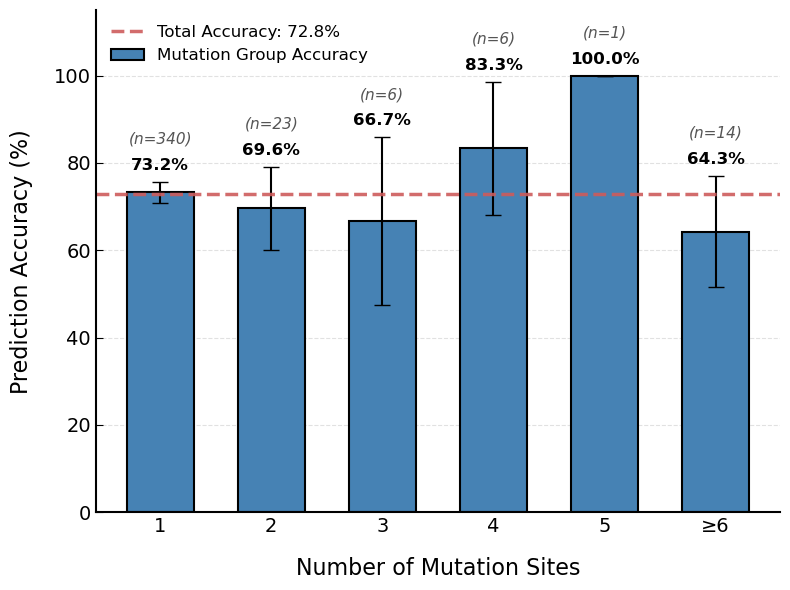

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data
df = pd.read_csv('single_wt_evaluation_results.csv')

def group_mutations(n):
    if pd.isna(n): return 'Unknown'
    return '≥6' if n >= 6 else str(int(n))

df['mut_group'] = df['mutation_sites_count'].apply(group_mutations)
group_order = ['1', '2', '3', '4', '5', '≥6']

acc_grouped = df.groupby('mut_group')['is_correct'].agg(
    total='count', 
    correct='sum'
).reindex(group_order).reset_index()

acc_grouped['accuracy'] = (acc_grouped['correct'] / acc_grouped['total']) * 100
p = acc_grouped['correct'] / acc_grouped['total']
acc_grouped['se'] = np.sqrt(p * (1 - p) / acc_grouped['total']) * 100
overall_acc = (df['is_correct'].sum() / len(df)) * 100

# Style
plt.rcParams.update({
    'font.family': 'sans-serif', 
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'sans-serif'],
    'axes.linewidth': 1.5,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'axes.unicode_minus': False
})

fig, ax = plt.subplots(figsize=(8, 6))

ax.yaxis.grid(True, linestyle='--', color='#D5D5D5', alpha=0.7)
ax.set_axisbelow(True)

bar_color = '#4682B4'
line_color = '#CD5C5C'

bars = ax.bar(
    acc_grouped['mut_group'], acc_grouped['accuracy'], 
    yerr=acc_grouped['se'],
    color=bar_color, edgecolor='black', linewidth=1.5, width=0.6, 
    capsize=6, error_kw={'elinewidth': 1.5, 'ecolor': 'black'},
    label='Mutation Group Accuracy'
)

ax.set_ylim(0, 115)
ax.set_xlabel('Number of Mutation Sites', fontsize=16, labelpad=15)
ax.set_ylabel('Prediction Accuracy (%)', fontsize=16, labelpad=15)
ax.tick_params(axis='both', labelsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.axhline(overall_acc, color=line_color, linestyle='--', linewidth=2.5, alpha=0.9, 
           label=f'Total Accuracy: {overall_acc:.1f}%')

for i, bar in enumerate(bars):
    acc_val = acc_grouped.iloc[i]['accuracy']
    n_val = acc_grouped.iloc[i]['total']
    se_val = acc_grouped.iloc[i]['se']
    
    if pd.isna(acc_val): continue
    base_y = max(acc_val + se_val, acc_val)
    
    ax.text(bar.get_x() + bar.get_width()/2, base_y + 2, f'{acc_val:.1f}%', 
            ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')

    ax.text(bar.get_x() + bar.get_width()/2, base_y + 8, f'(n={int(n_val)})', 
            ha='center', va='bottom', fontsize=11, color='#555555', fontstyle='italic')

ax.legend(frameon=False, loc='upper left', fontsize=12)

plt.tight_layout()
# plt.savefig("./Figure/Mutation_Site_Accuracy.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()